# RFM 고객 세분화 분석

고객의 최근 구매 시점, 구매 횟수, 구매 금액을 이용해 RFM 등급을 나누고 고객군별 특징을 확인했다. 등급별 매출 차이와 인구통계, 품목, 프로모션 반응을 같이 살펴본다.

## 분석 목표

1. RFM 지표로 고객을 3개 등급으로 나눈다.
2. 등급별 고객 수와 매출 기여도를 비교한다.
3. 고객 특성과 구매 행동을 확인해 마케팅 방향을 제안한다.

In [1]:
!sudo apt-get install -y fonts-nanum
import matplotlib.font_manager as fm
# 설치된 나눔고딕 폰트를 폰트 매니저에 추가
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


## 1. 데이터 확인

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option('display.max_columns', None)

# GitHub/Jupyter에서는 같은 폴더, Colab에서는 /content 경로를 확인한다.
data_path = Path('customer_data.csv')
if not data_path.exists():
    data_path = Path('/content/customer_data.csv')

df = pd.read_csv(data_path, sep='	')
df.head()

,ID,signup_ym,birth_year,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,num_purchase_web,num_purchase_store,num_purchase_discount,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,revenue
0,5524,2020-12,1965,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,8,4,3,0,0,0,0,0,1,11
1,2174,2022-06,1962,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,1,2,2,0,0,0,0,0,0,11
2,4141,2021-11,1973,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,8,10,1,0,0,0,0,0,0,11
3,6182,2022-05,1992,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,2,4,2,0,0,0,0,0,0,11
4,5324,2022-04,1989,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,5,6,5,0,0,0,0,0,0,11


In [3]:
print(f'데이터 크기: {df.shape[0]:,}행, {df.shape[1]}열')
print(f'중복 행: {df.duplicated().sum()}개')
print(f'중복 ID: {df["ID"].duplicated().sum()}개')

df.isna().sum()[df.isna().sum() > 0]

데이터 크기: 2,240행, 23열
중복 행: 0개
중복 ID: 0개


,0
annual_income,24


전체 2,240명의 고객이 있고 ID 중복은 없다. 결측치는 연 소득에만 24개가 있다. 원본 분석과 동일하게 연 소득 평균으로 결측치를 채웠다.


## 2. 전처리와 파생 변수

In [4]:
# 데이터가 만들어진 시점(2023년)을 기준으로 나이 계산
df['age'] = 2023 - df['birth_year']

q1 = df['age'].quantile(0.25)
q3 = df['age'].quantile(0.75)

iqr = q3-q1
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

cond1 = df['age']<lower
cond2 = df['age']>upper

age_outliers = df[cond1|cond2] # 이상값 확인

print(f'제외한 나이 이상값: {len(age_outliers)}명')

df = df[df['age']<115] #이상값 제거

제외한 나이 이상값: 3명


In [6]:
# 연 소득 결측치는 원본과 동일하게 평균으로 대체
df['annual_income'] = df['annual_income'].fillna(df['annual_income'].mean())

# ID를 기준으로 정렬한 뒤 파생 변수 생성
df = df.set_index('ID').sort_index()

amount_columns = [
    'amount_alcohol', 'amount_fruit', 'amount_meat',
    'amount_fish', 'amount_snack', 'amount_general'
]

df['total_amount'] = df[amount_columns].sum(axis=1)

# Frequency는 실제 구매 채널인 웹과 매장 구매 횟수만 사용
# 할인 구매 횟수는 중복 가능성이 있어 고객 성향 분석용으로 따로 보관
df['num_purchase'] = df['num_purchase_web'] + df['num_purchase_store']

df = df.reset_index()
df = df.drop(columns=['ID', 'revenue'])

# IQR 기준으로 연 소득 이상값 제거
income_q1 = df['annual_income'].quantile(0.25)
income_q3 = df['annual_income'].quantile(0.75)
income_iqr = income_q3 - income_q1
income_lower = income_q1 - 1.5 * income_iqr
income_upper = income_q3 + 1.5 * income_iqr

income_outliers = (~df['annual_income'].between(income_lower, income_upper)).sum()
df = df[df['annual_income'].between(income_lower, income_upper)].copy()

print(f'제외한 연 소득 이상값: {income_outliers}명')
print(f'최종 분석 고객: {len(df):,}명')

제외한 연 소득 이상값: 0명
최종 분석 고객: 2,229명


In [12]:
df['annual_income']

,annual_income
0,92236300.0
1,74218300.0
2,59927400.0
3,32965400.0
4,78638300.0
...,...
2224,85758400.0
2225,55112200.0
2226,34433100.0
2227,33918300.0


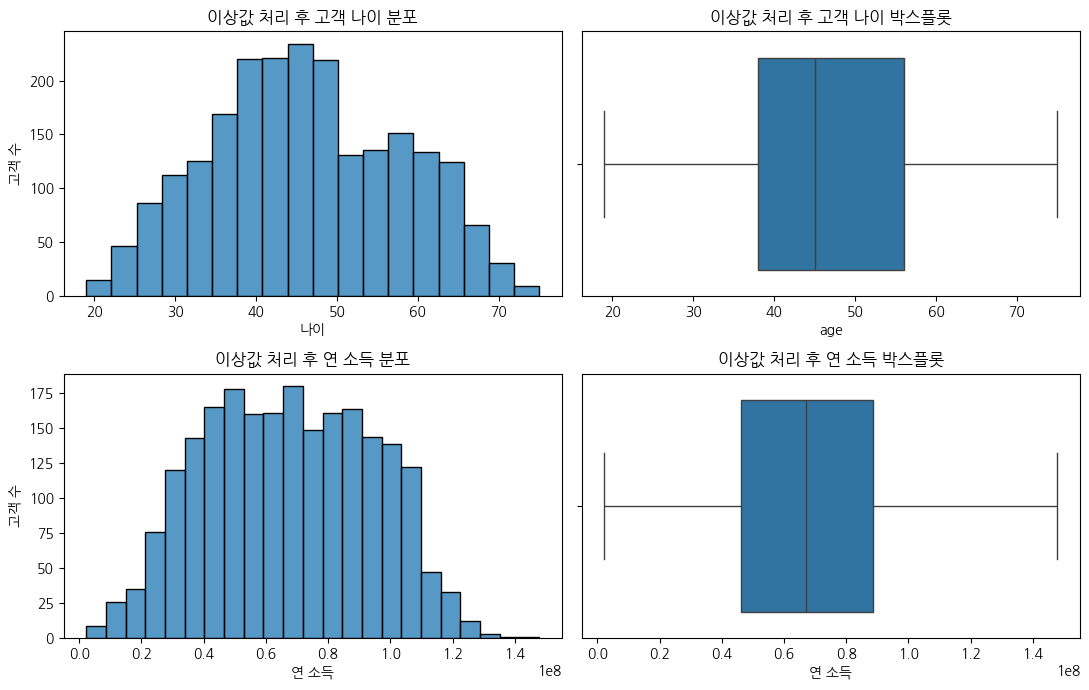

In [15]:
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

sns.histplot(data=df, x='age', bins=18, ax=axes[0, 0])
axes[0, 0].set_title('이상값 처리 후 고객 나이 분포')
axes[0, 0].set_xlabel('나이')
axes[0, 0].set_ylabel('고객 수')

sns.boxplot(data=df, x='age', ax=axes[0, 1])
axes[0, 1].set_title('이상값 처리 후 고객 나이 박스플롯')

sns.histplot(data=df, x='annual_income', ax=axes[1, 0])
axes[1, 0].set_title('이상값 처리 후 연 소득 분포')
axes[1, 0].set_xlabel('연 소득')
axes[1, 0].set_ylabel('고객 수')

sns.boxplot(data=df, x='annual_income', ax=axes[1, 1])
axes[1, 1].set_title('이상값 처리 후 연 소득 박스플롯')
axes[1, 1].set_xlabel('연 소득')


plt.tight_layout()
plt.show()


나이는 40대를 중심으로 분포한다. 115세 이상인 고객 3명과 연 소득 IQR 범위를 벗어난 고객 8명을 제외했고, 최종 2,229명을 분석에 사용했다. `num_purchase_discount`는 삭제하지 않고 이후 고객 성향 분석에 사용한다.


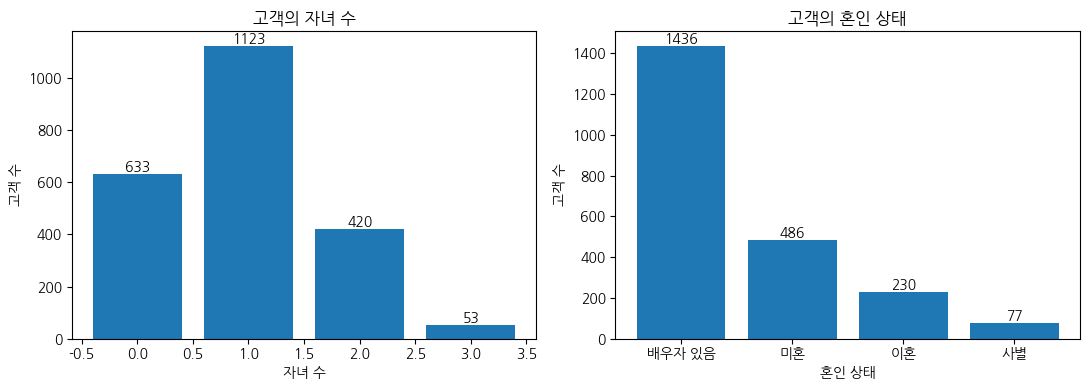

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

children_count = df['children'].value_counts().sort_index()
axes[0].bar(children_count.index, children_count.values)
axes[0].set_title('고객의 자녀 수')
axes[0].set_xlabel('자녀 수')
axes[0].set_ylabel('고객 수')
axes[0].bar_label(axes[0].containers[0])

marital_count = df['marital_status'].value_counts()
axes[1].bar(marital_count.index, marital_count.values)
axes[1].set_title('고객의 혼인 상태')
axes[1].set_xlabel('혼인 상태')
axes[1].set_ylabel('고객 수')
axes[1].bar_label(axes[1].containers[0])

plt.tight_layout()
plt.show()

자녀가 1명인 고객과 배우자가 있는 고객이 가장 많다.

## 3. 변수 간 관계

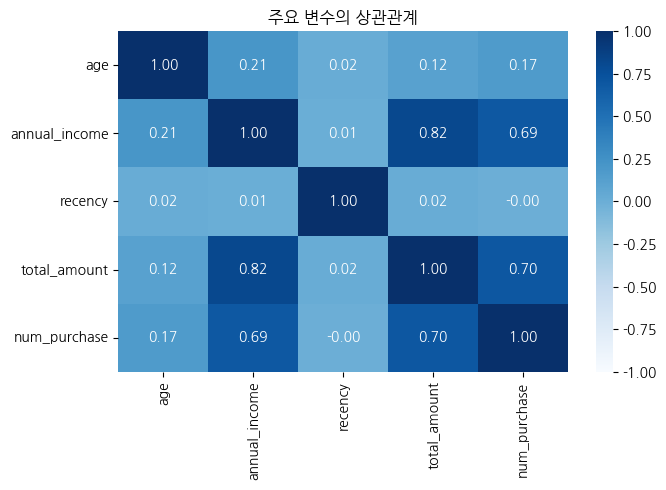

In [20]:
corr_columns = ['age', 'annual_income', 'recency', 'total_amount', 'num_purchase']
corr = df[corr_columns].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', vmin=-1, vmax=1)
plt.title('주요 변수의 상관관계')
plt.tight_layout()
plt.show()

총 구매 금액과 구매 횟수의 상관계수는 0.70이다. 연 소득과 총 구매 금액도 0.82로 양의 관계가 보인다. Recency는 다른 지표와 상관관계가 거의 없어 구매 규모와 다른 정보를 보여준다.


## 4. RFM 점수 계산

RFM은 다음 세 가지 기준을 사용한다.

- Recency: 마지막 구매 후 경과일. 작을수록 좋다.
- Frequency: 웹 구매 횟수와 매장 구매 횟수의 합계
- Monetary: 전체 품목 구매 금액의 합계

각 지표를 `pd.qcut`으로 4개 구간으로 나누어 1~4점을 부여했다. Recency는 값이 작을수록 좋으므로 라벨을 반대 순서로 설정했다. 할인 구매 횟수는 웹·매장 구매와 중복될 수 있어 Frequency에서 제외하고 고객 성향 변수로 따로 사용했다.


In [21]:
df['recency_등급'] = pd.qcut(df['recency'], q=4, labels=[4, 3, 2, 1]).astype(int)
df['frequency_등급'] = pd.qcut(df['num_purchase'], q=4, labels=[1, 2, 3, 4]).astype(int)
df['monetary_등급'] = pd.qcut(df['total_amount'], q=4, labels=[1, 2, 3, 4]).astype(int)

rfm_range = pd.DataFrame({
    'Recency 범위': df.groupby('recency_등급')['recency'].agg(lambda x: f'{x.min()}~{x.max()}일'),
    'Frequency 범위': df.groupby('frequency_등급')['num_purchase'].agg(lambda x: f'{x.min()}~{x.max()}회'),
    'Monetary 범위': df.groupby('monetary_등급')['total_amount'].agg(lambda x: f'{x.min():,.0f}~{x.max():,.0f}원')
})
rfm_range.index.name = '등급'
rfm_range

,Recency 범위,Frequency 범위,Monetary 범위
등급,,,
1,75~99일,0~5회,"6,500~89,700원"
2,50~74일,6~10회,"91,000~516,100원"
3,25~49일,11~14회,"517,400~1,357,200원"
4,0~24일,15~27회,"1,358,500~3,282,500원"


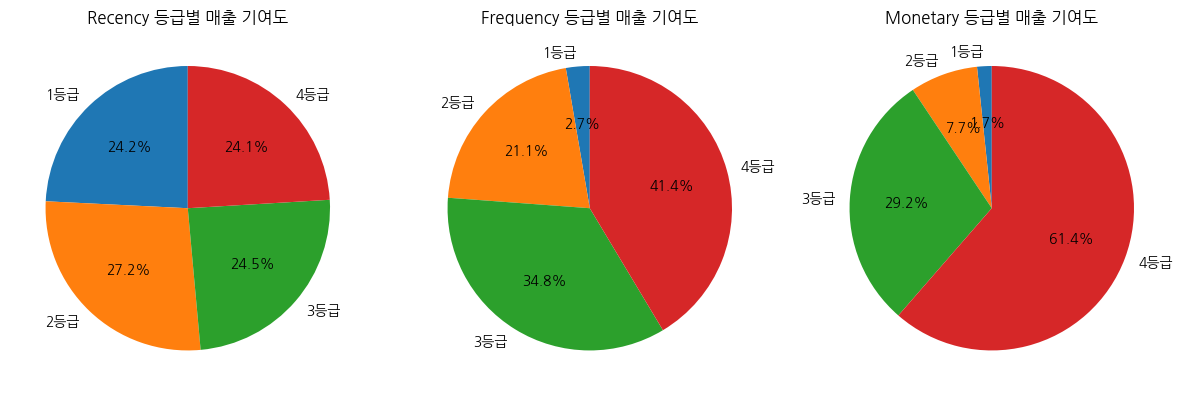

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, grade_column, title in zip(
    axes,
    ['recency_등급', 'frequency_등급', 'monetary_등급'],
    ['Recency 등급별 매출 기여도', 'Frequency 등급별 매출 기여도', 'Monetary 등급별 매출 기여도']
):

    revenue = df.groupby(grade_column)['total_amount'].sum().sort_index()

    ax.pie(
        revenue,
        autopct='%.1f%%',
        labels=[f'{grade}등급' for grade in revenue.index],
        startangle=90
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()


Recency는 등급별 매출 비중이 24.0~27.2%로 비슷하다. 반면 Monetary 4등급은 전체 매출의 61.4%, Frequency 4등급은 41.4%를 차지한다. Frequency와 Monetary가 매출 차이를 더 크게 보여서  F·M에 0.4, R에 0.2의 가중치를 사용했다. 이 가중치는 현재 데이터에서 세그먼트를 비교하기 위한 기준이다.


In [32]:
r_weight = 0.2
f_weight = 0.4
m_weight = 0.4

df['RFM'] = (
    df['recency_등급'] * r_weight
    + df['frequency_등급'] * f_weight
    + df['monetary_등급'] * m_weight
)

df['RFM_group'] = pd.cut(df['RFM'], bins=3, labels=[1, 2, 3]).astype(int)

rfm_summary = df.groupby('RFM_group').agg(
    고객수=('RFM', 'size'),
    매출=('total_amount', 'sum'),
    평균_Recency=('recency', 'mean'),
    평균_구매횟수=('num_purchase', 'mean'),
    평균_구매금액=('total_amount', 'mean'),
    평균_연소득=('annual_income', 'mean')
)

rfm_summary['고객비중'] = rfm_summary['고객수'] / len(df)
rfm_summary['매출비중'] = rfm_summary['매출'] / df['total_amount'].sum()
rfm_summary.round(2)


,고객수,매출,평균_Recency,평균_구매횟수,평균_구매금액,평균_연소득,고객비중,매출비중
RFM_group,,,,,,,,
1,873,93973100,54.66,4.96,107643.87,43897682.84,0.39,0.05
2,621,543578100,53.72,10.37,875327.05,73461670.84,0.28,0.31
3,735,1117125100,38.61,15.41,1519898.10,89336246.72,0.33,0.64


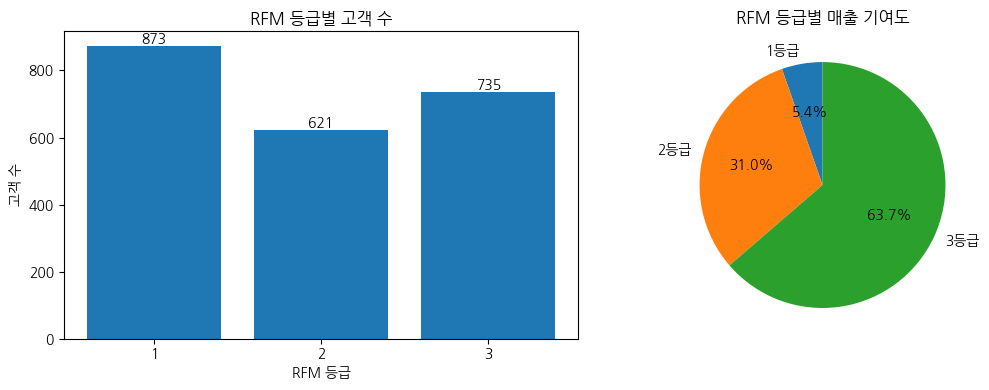

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

customer_count = rfm_summary['고객수']
axes[0].bar(customer_count.index.astype(str), customer_count.values)
axes[0].bar_label(axes[0].containers[0])
axes[0].set_title('RFM 등급별 고객 수')
axes[0].set_xlabel('RFM 등급')
axes[0].set_ylabel('고객 수')

axes[1].pie(
    rfm_summary['매출'],
    autopct='%.1f%%',
    labels=[f'{grade}등급' for grade in rfm_summary.index],
    startangle=90
)
axes[1].set_title('RFM 등급별 매출 기여도')

plt.tight_layout()
plt.show()

3등급 고객은 735명으로 전체의 33.0%이며 매출의 63.7%를 만든다. 1등급은 873명으로 고객 수가 가장 많지만 매출 비중은 5.4%다. 고객 수만 보는 것보다 고객당 구매 금액을 같이 보는 것이 중요하다.


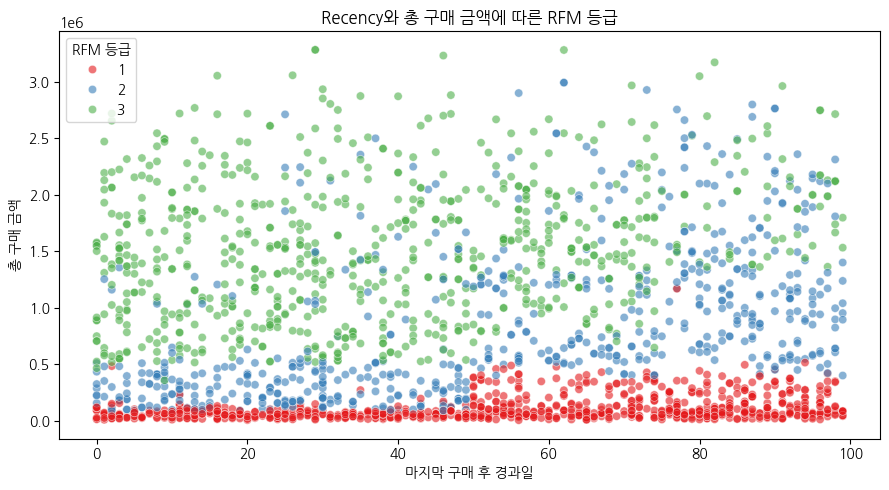

In [34]:
# 최근 구매일과 총 구매 금액을 한 번에 비교한다.
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x='recency',
    y='total_amount',
    hue='RFM_group',
    palette='Set1',
    alpha=0.6
)
plt.title('Recency와 총 구매 금액에 따른 RFM 등급')
plt.xlabel('마지막 구매 후 경과일')
plt.ylabel('총 구매 금액')
plt.legend(title='RFM 등급')
plt.tight_layout()
plt.show()

3등급은 구매 금액이 큰 고객이 많고 Recency도 비교적 짧다. 다만 구매 금액이 크면서 Recency가 긴 고객도 있다. 이런 고객은 이탈 가능성을 따로 확인할 필요가 있다.

## 5. RFM 등급별 고객 특성

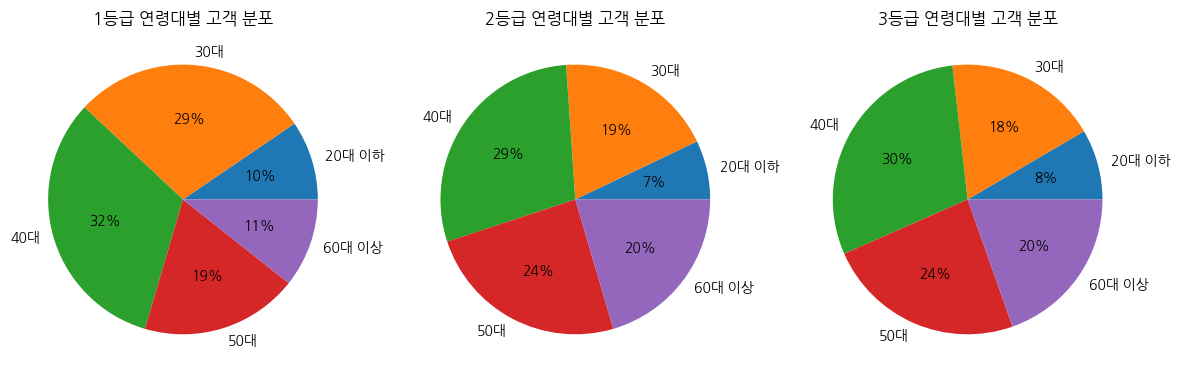

In [37]:
# 10대랑 70대 숫자가 너무 적어 연령대 범위를 수정
df.loc[(df['age']>=10)&(df['age']<20),'age_group']='20대 이하'
df.loc[(df['age']>=20)&(df['age']<30),'age_group']='20대 이하'
df.loc[(df['age']>=30)&(df['age']<40),'age_group']='30대'
df.loc[(df['age']>=40)&(df['age']<50),'age_group']='40대'
df.loc[(df['age']>=50)&(df['age']<60),'age_group']='50대'
df.loc[(df['age']>=60)&(df['age']<70),'age_group']='60대 이상'
df.loc[(df['age']>=70)&(df['age']<80),'age_group']='60대 이상'

age_table = df.groupby(['RFM_group', 'age_group'], observed=True).size().reset_index(name='num_customer')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for grade, ax in zip([1, 2, 3], axes):
    group = age_table[age_table['RFM_group'] == grade]
    ax.pie(group['num_customer'], autopct='%1.f%%', labels=group['age_group'])
    ax.set_title(f'{grade}등급 연령대별 고객 분포')

plt.tight_layout()
plt.show()

모든 등급에서 40대 비중이 가장 크다. 1등급은 30~40대 비중이 상대적으로 높고, 2·3등급은 50대 이상 비중이 더 높다. 연령만으로 RFM 등급을 설명하기는 어렵다.


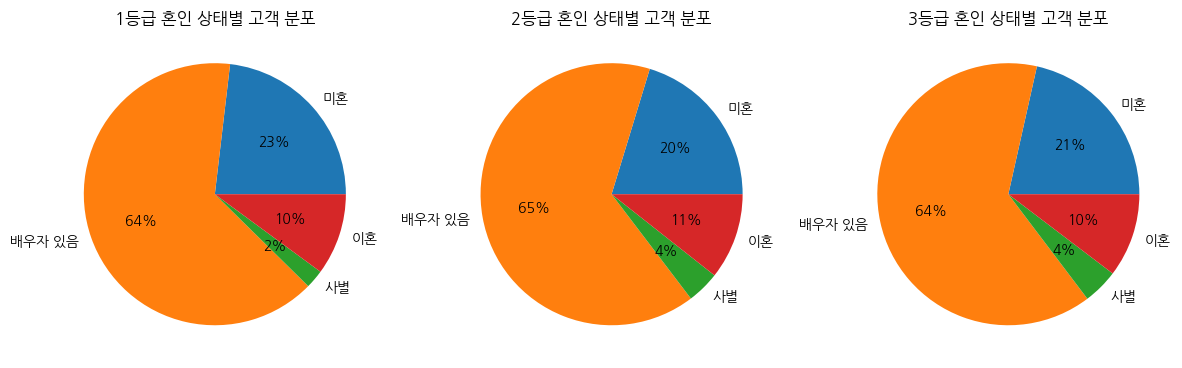

In [39]:
marital_table = df.groupby(['RFM_group', 'marital_status']).size().reset_index(name='num_customer')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for grade, ax in zip([1, 2, 3], axes):
    group = marital_table[marital_table['RFM_group'] == grade]
    ax.pie(group['num_customer'], autopct='%1.f%%', labels=group['marital_status'])
    ax.set_title(f'{grade}등급 혼인 상태별 고객 분포')

plt.tight_layout()
plt.show()

모든 등급에서 배우자가 있는 고객의 비중이 63.8~65.1%로 비슷하다. 혼인 상태는 RFM 등급을 구분하는 큰 특징은 아닌 것으로 보인다.


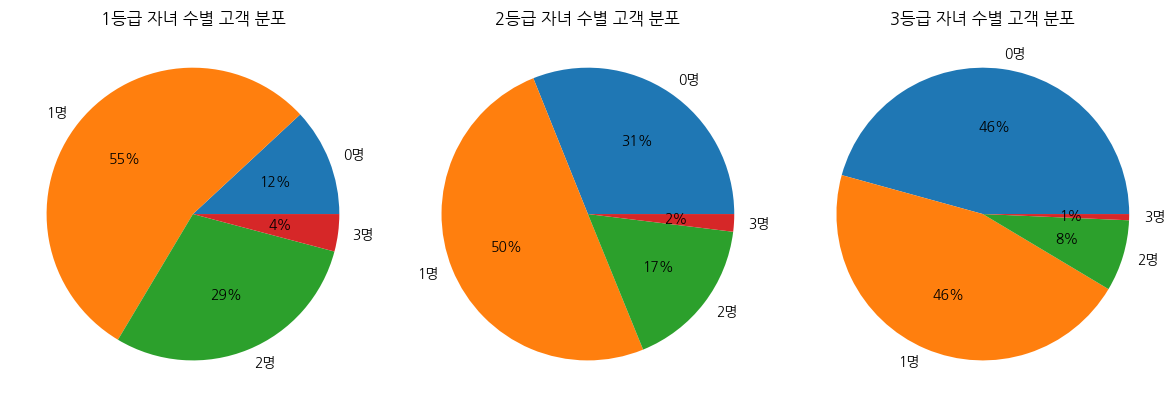

In [40]:
children_table = df.groupby(['RFM_group', 'children']).size().reset_index(name='num_customer')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for grade, ax in zip([1, 2, 3], axes):
    group = children_table[children_table['RFM_group'] == grade]
    ax.pie(
        group['num_customer'],
        autopct='%1.f%%',
        labels=[f'{value}명' for value in group['children']]
    )
    ax.set_title(f'{grade}등급 자녀 수별 고객 분포')

plt.tight_layout()
plt.show()

RFM 등급이 높아질수록 자녀가 없는 고객의 비중이 커진다. 1등급은 11.9%, 3등급은 45.7%다. 다만 이 결과만으로 자녀 유무가 구매 금액에 영향을 준다고 단정할 수는 없다.


## 6. 품목, 프로모션, 구매 방식 분석

In [42]:
amount_columns

['amount_alcohol',
 'amount_fruit',
 'amount_meat',
 'amount_fish',
 'amount_snack',
 'amount_general']

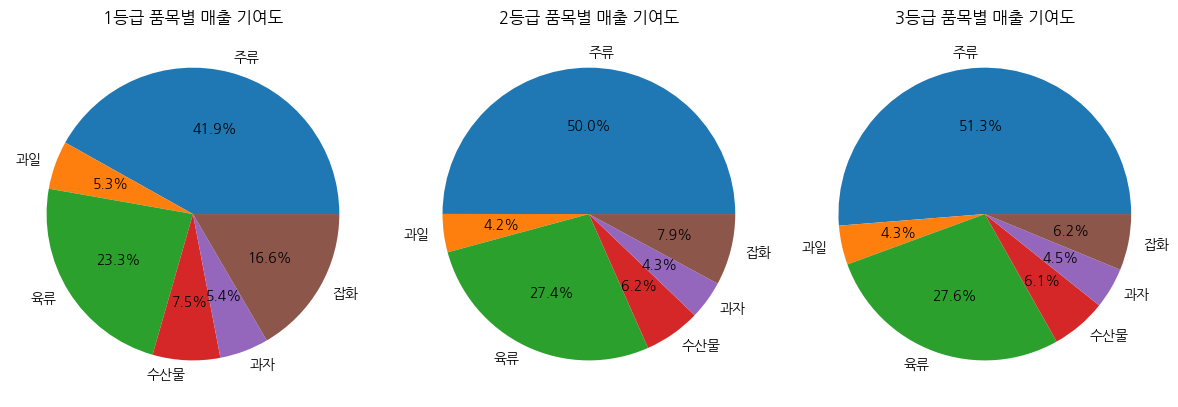

In [45]:
product_table = df.groupby('RFM_group')[amount_columns].sum()
product_labels = ['주류', '과일', '육류', '수산물', '과자', '잡화']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for grade, ax in zip([1, 2, 3], axes):
    ax.pie(
        product_table.loc[grade],
        autopct='%.1f%%',
        labels=product_labels
    )
    ax.set_title(f'{grade}등급 품목별 매출 기여도')

plt.tight_layout()
plt.show()

등급이 높아질수록 주류 매출 비중이 커진다. 1등급의 주류 비중은 41.9%, 3등급은 51.3%다. 반면 잡화 비중은 1등급 16.6%에서 3등급 6.2%로 줄어든다.


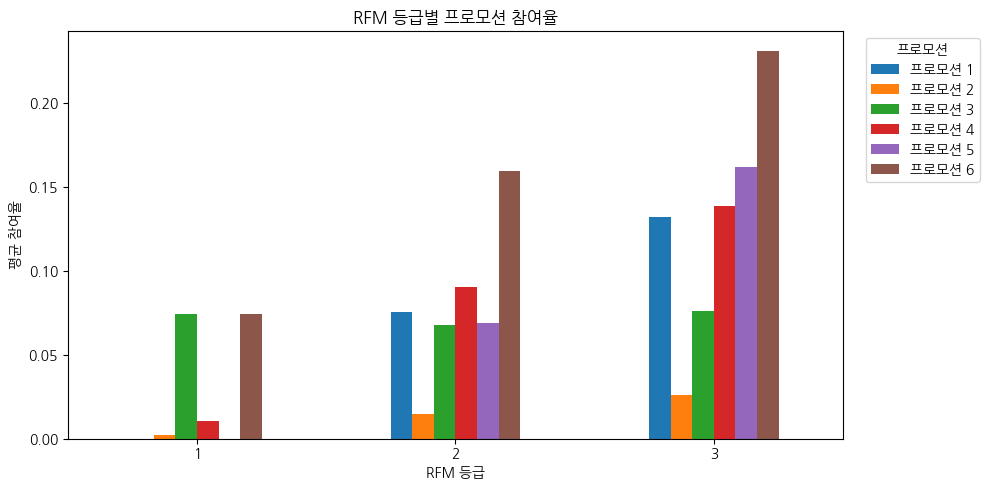

In [48]:
promotion_columns = [f'promotion_{i}' for i in range(1, 7)]
promotion_table = df.groupby('RFM_group')[promotion_columns].mean()
promotion_table.columns = [f'프로모션 {i}' for i in range(1, 7)]

promotion_table.plot(kind='bar', figsize=(10, 5))
plt.title('RFM 등급별 프로모션 참여율')
plt.xlabel('RFM 등급')
plt.ylabel('평균 참여율')
plt.xticks(rotation=0)
plt.legend(title='프로모션', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

3등급은 대부분의 프로모션에서 참여율이 높다. 특히 프로모션 6은 3등급 참여율이 23.1%로 가장 높았다. 전반적으로 RFM 등급이 높을수록 대부분의 프로모션 참여율이 뚜렷하게 증가하는 경향을 보입니다.


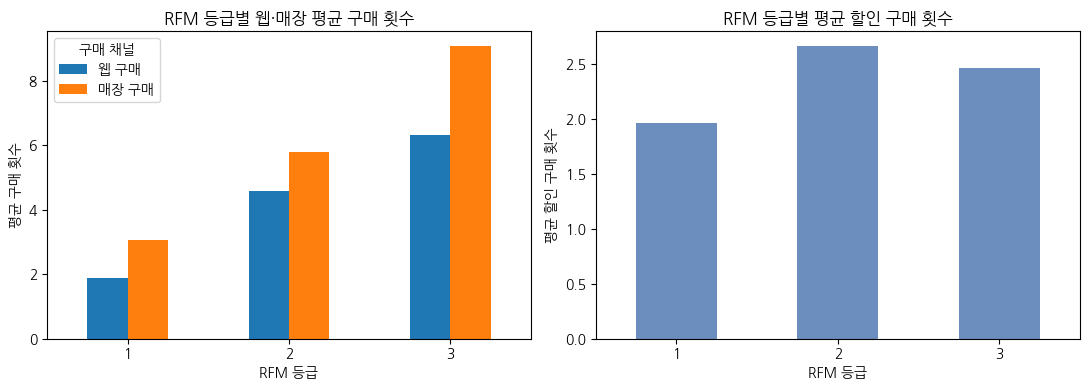

In [49]:
# 웹·매장 구매는 Frequency에 사용한 실제 구매 채널
purchase_columns = ['num_purchase_web', 'num_purchase_store']
purchase_table = df.groupby('RFM_group')[purchase_columns].mean()
purchase_table.columns = ['웹 구매', '매장 구매']

# 할인 구매 횟수는 RFM 산식과 분리해 고객 성향으로 확인
discount_table = df.groupby('RFM_group')['num_purchase_discount'].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

purchase_table.plot(kind='bar', ax=axes[0])
axes[0].set_title('RFM 등급별 웹·매장 평균 구매 횟수')
axes[0].set_xlabel('RFM 등급')
axes[0].set_ylabel('평균 구매 횟수')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='구매 채널')

discount_table.plot(kind='bar', ax=axes[1], color='#6C8EBF')
axes[1].set_title('RFM 등급별 평균 할인 구매 횟수')
axes[1].set_xlabel('RFM 등급')
axes[1].set_ylabel('평균 할인 구매 횟수')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


모든 등급에서 매장 구매 횟수가 웹 구매보다 많다. 3등급의 평균 매장 구매는 9.1회, 웹 구매는 6.3회다. 할인 구매 횟수는 2등급이 평균 2.66회로 가장 높아 RFM 등급과 단순히 비례하지 않았다. 따라서 할인 반응은 RFM 점수와 별개의 고객 성향으로 보는 편이 적절하다.


## 7. 결론

- 3등급 고객은 전체 고객의 33.0%이지만 매출의 63.7%를 차지한다.
- 3등급은 평균 구매 횟수가 15.4회, 평균 구매 금액이 약 152만 원으로 가장 높다.
- 3등급의 주류 매출 비중과 프로모션 참여율이 높아 주류 관련 혜택이나 VIP 캠페인을 우선 검토할 수 있다.
- 할인 구매 횟수는 2등급에서 가장 높아 RFM 점수와 별도로 할인 선호 고객을 찾는 데 활용할 수 있다.
- 구매 금액은 크지만 Recency가 긴 고객은 이탈 가능성이 있으므로 별도의 재구매 캠페인 대상으로 확인할 필요가 있다.

## 분석의 한계

- 거래별 날짜가 없어 고객의 구매 주기와 재구매율은 확인하지 못했다.
- RFM 구간은 현재 고객 분포에 따른 상대적인 기준이다.
- 할인 구매가 웹·매장 구매에 포함되는지는 데이터 정의만으로 확인하기 어렵다. 중복 가능성을 고려해 Frequency에서는 제외했다.
- R·F·M 가중치는 탐색적으로 정한 값이므로 실제 캠페인 성과로 검증할 필요가 있다.
